# Analysis: Original vs Optimized — Branch Length Estimation

**Comparison of:** `2026_03_16_bl_estimation` (original) vs `2026_03_16_bl_estimation_opt` (optimized)  
**Dataset:** 100 taxa, 1M sites, 10 different trees, 10 runs each  
**Optimized combos:**  
- DNA GTR rooted/unrooted — OPENACC (GPU V100)  
- AA LG unrooted — OPENACC (GPU V100)  
- AA Poisson rooted/unrooted — VANILA (CPU 1 core)  

**Mode:** Branch length estimation (no `-blfix`) — parameters and branch lengths are optimized

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
original_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation"
opt_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_16_bl_estimation_opt"

# 1. Parse all log files

In [2]:
alignment_pattern = re.compile(r"Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns")
initial_ll_pattern = re.compile(r"Initial log-likelihood:\s+([-0-9.]+)")
optimal_ll_pattern = re.compile(r"Optimal log-likelihood:\s+([-0-9.]+)")
params_opt_pattern = re.compile(r"Parameters optimization took (\d+) rounds? \(([0-9.]+) sec\)")
wallclock_pattern = re.compile(r"Total wall-clock time used:\s+([0-9.]+)\s+sec")

In [3]:
def parse_all_logs(results_path, source_label="original"):
    """Parse all IQ-TREE log files and extract timing/likelihood data for BL estimation."""
    rows = []
    skipped = 0

    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir):
            continue

        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir):
                continue

            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir):
                    continue

                for tree_folder in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_folder)
                    if not os.path.isdir(tree_dir):
                        continue

                    for fname in os.listdir(tree_dir):
                        if not fname.endswith('.log'):
                            continue

                        filepath = os.path.join(tree_dir, fname)
                        with open(filepath, 'r') as f:
                            content = f.read()

                        # Determine backend from filename
                        if 'OPENACC' in fname:
                            backend = 'IQ-TREE_GPU_V100'
                        elif 'OMP_48' in fname:
                            backend = 'IQ-TREE_CPU_48cores'
                        elif 'OMP_10' in fname:
                            backend = 'IQ-TREE_CPU_10cores'
                        elif 'VANILA' in fname:
                            backend = 'IQ-TREE_CPU_1core'
                        else:
                            continue

                        # Extract run number — use LAST match to handle doubled filename patterns
                        # e.g. output_test_..._VANILA_run1_tree_1_..._VANILA_run8_tree_1_...
                        run_matches = re.findall(r'_run(\d+)_', fname)
                        run_number = int(run_matches[-1]) if run_matches else None

                        # Extract metrics
                        aln_match = alignment_pattern.search(content)
                        init_ll_match = initial_ll_pattern.search(content)
                        opt_ll_match = optimal_ll_pattern.search(content)
                        opt_match = params_opt_pattern.search(content)
                        wc_match = wallclock_pattern.search(content)

                        if aln_match and init_ll_match and opt_match and wc_match:
                            rows.append({
                                'source': source_label,
                                'data_type': data_type,
                                'tree_type': tree_type,
                                'model': model,
                                'treefile': tree_folder,
                                'backend': backend,
                                'run': run_number,
                                'taxa': int(aln_match.group(1)),
                                'sites': int(aln_match.group(2)),
                                'patterns': int(aln_match.group(3)),
                                'initial_likelihood': float(init_ll_match.group(1)),
                                'optimal_likelihood': float(opt_ll_match.group(1)) if opt_ll_match else float(init_ll_match.group(1)),
                                'opt_rounds': int(opt_match.group(1)),
                                'opt_time': float(opt_match.group(2)),
                                'wallclock_time': float(wc_match.group(1)),
                            })
                        else:
                            skipped += 1

    df = pd.DataFrame(rows)
    print(f"[{source_label}] Parsed {len(df)} log files ({skipped} skipped due to incomplete output)")
    return df

df_orig_full = parse_all_logs(original_path, "original")
df_opt = parse_all_logs(opt_path, "optimized")

[original] Parsed 6396 log files (4 skipped due to incomplete output)


[optimized] Parsed 200 log files (0 skipped due to incomplete output)


# 2. Data overview

In [4]:
print("=== Optimized data breakdown ===")
print(df_opt.groupby(['data_type','tree_type','model','backend']).size().reset_index(name='count'))

# Identify the combos present in opt
opt_combos = df_opt[['data_type','tree_type','model','backend']].drop_duplicates()
print(f"\nOpt combos:\n{opt_combos.to_string()}")

=== Optimized data breakdown ===
  data_type tree_type model           backend  count
0        AA  unrooted    LG  IQ-TREE_GPU_V100    100
1       DNA  unrooted   GTR  IQ-TREE_GPU_V100    100

Opt combos:
    data_type tree_type model           backend
0          AA  unrooted    LG  IQ-TREE_GPU_V100
100       DNA  unrooted   GTR  IQ-TREE_GPU_V100


In [5]:
# Build original subset matching opt combos
df_orig = pd.DataFrame()
for _, row in opt_combos.iterrows():
    mask = ((df_orig_full['data_type'] == row['data_type']) & 
            (df_orig_full['tree_type'] == row['tree_type']) &
            (df_orig_full['model'] == row['model']) & 
            (df_orig_full['backend'] == row['backend']))
    df_orig = pd.concat([df_orig, df_orig_full[mask]])

print(f"Original (matching combos): {len(df_orig)} rows")
print(df_orig.groupby(['data_type','tree_type','model','backend']).size().reset_index(name='count'))

# Combine
df_all = pd.concat([df_orig, df_opt], ignore_index=True)
df_all['combo'] = df_all['data_type'] + '\n' + df_all['model'] + '\n' + df_all['tree_type']

Original (matching combos): 196 rows
  data_type tree_type model           backend  count
0        AA  unrooted    LG  IQ-TREE_GPU_V100    100
1       DNA  unrooted   GTR  IQ-TREE_GPU_V100     96


# 3. Statistical comparison

In [6]:
print("=" * 80)
print("COMPARISON: ORIGINAL vs OPTIMIZED")
print("=" * 80)

for _, combo in opt_combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    orig_sub = df_orig[(df_orig['data_type']==dt) & (df_orig['tree_type']==tt) & 
                       (df_orig['model']==model) & (df_orig['backend']==backend)]
    opt_sub = df_opt[(df_opt['data_type']==dt) & (df_opt['tree_type']==tt) & 
                     (df_opt['model']==model) & (df_opt['backend']==backend)]
    
    print(f"\n--- {dt} | {tt} | {model} | {backend} ---")
    print(f"  Original:  n={len(orig_sub)}, opt_time median={orig_sub['opt_time'].median():.3f}s, "
          f"mean={orig_sub['opt_time'].mean():.3f}s, std={orig_sub['opt_time'].std():.3f}s")
    print(f"  Optimized: n={len(opt_sub)}, opt_time median={opt_sub['opt_time'].median():.3f}s, "
          f"mean={opt_sub['opt_time'].mean():.3f}s, std={opt_sub['opt_time'].std():.3f}s")
    if orig_sub['opt_time'].median() > 0:
        speedup = orig_sub['opt_time'].median() / opt_sub['opt_time'].median()
        pct_change = (opt_sub['opt_time'].median() - orig_sub['opt_time'].median()) / orig_sub['opt_time'].median() * 100
        print(f"  Speedup (median): {speedup:.2f}x  |  Change: {pct_change:+.1f}%")
    
    print(f"  Original:  wallclock median={orig_sub['wallclock_time'].median():.3f}s")
    print(f"  Optimized: wallclock median={opt_sub['wallclock_time'].median():.3f}s")
    if orig_sub['wallclock_time'].median() > 0:
        wc_speedup = orig_sub['wallclock_time'].median() / opt_sub['wallclock_time'].median()
        print(f"  Wallclock speedup (median): {wc_speedup:.2f}x")
    
    print(f"  Original:  opt_rounds median={orig_sub['opt_rounds'].median():.0f}, "
          f"range=[{orig_sub['opt_rounds'].min()}, {orig_sub['opt_rounds'].max()}]")
    print(f"  Optimized: opt_rounds median={opt_sub['opt_rounds'].median():.0f}, "
          f"range=[{opt_sub['opt_rounds'].min()}, {opt_sub['opt_rounds'].max()}]")
    
    print(f"  Original:  optimal_LL median={orig_sub['optimal_likelihood'].median():.4f}")
    print(f"  Optimized: optimal_LL median={opt_sub['optimal_likelihood'].median():.4f}")
    ll_diff = abs(opt_sub['optimal_likelihood'].median() - orig_sub['optimal_likelihood'].median())
    print(f"  LL difference (median): {ll_diff:.6f}")

COMPARISON: ORIGINAL vs OPTIMIZED

--- AA | unrooted | LG | IQ-TREE_GPU_V100 ---
  Original:  n=100, opt_time median=15.394s, mean=14.795s, std=1.307s
  Optimized: n=100, opt_time median=15.380s, mean=14.783s, std=1.306s
  Speedup (median): 1.00x  |  Change: -0.1%
  Original:  wallclock median=18.235s
  Optimized: wallclock median=18.230s
  Wallclock speedup (median): 1.00x
  Original:  opt_rounds median=1, range=[1, 1]
  Optimized: opt_rounds median=1, range=[1, 1]
  Original:  optimal_LL median=-86924195.8055
  Optimized: optimal_LL median=-86924195.8055
  LL difference (median): 0.000000

--- DNA | unrooted | GTR | IQ-TREE_GPU_V100 ---
  Original:  n=96, opt_time median=14.806s, mean=16.287s, std=2.980s
  Optimized: n=100, opt_time median=14.503s, mean=15.805s, std=2.809s
  Speedup (median): 1.02x  |  Change: -2.0%
  Original:  wallclock median=17.581s
  Optimized: wallclock median=17.301s
  Wallclock speedup (median): 1.02x
  Original:  opt_rounds median=4, range=[4, 8]
  Optimized

# 4. Plot setup

In [7]:
BACKEND_PALETTE = {
    'IQ-TREE_CPU_1core': '#1565C0', 'IQ-TREE_CPU_10cores': '#757575',
    'IQ-TREE_CPU_48cores': '#2E7D32', 'IQ-TREE_GPU_V100': '#E65100',
}
BACKEND_ORDER = ['IQ-TREE_CPU_1core', 'IQ-TREE_CPU_10cores', 'IQ-TREE_CPU_48cores', 'IQ-TREE_GPU_V100']
SOURCE_PALETTE = {'original': '#1565C0', 'optimized': '#E65100'}

sns.set_style("whitegrid")
sns.set_context("talk")
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 11, 'figure.titlesize': 16,
    'axes.linewidth': 1.2, 'lines.linewidth': 2,
    'savefig.bbox': 'tight', 'savefig.pad_inches': 0.15,
    'figure.facecolor': 'white', 'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
})

# 5. Optimization time comparison per tree

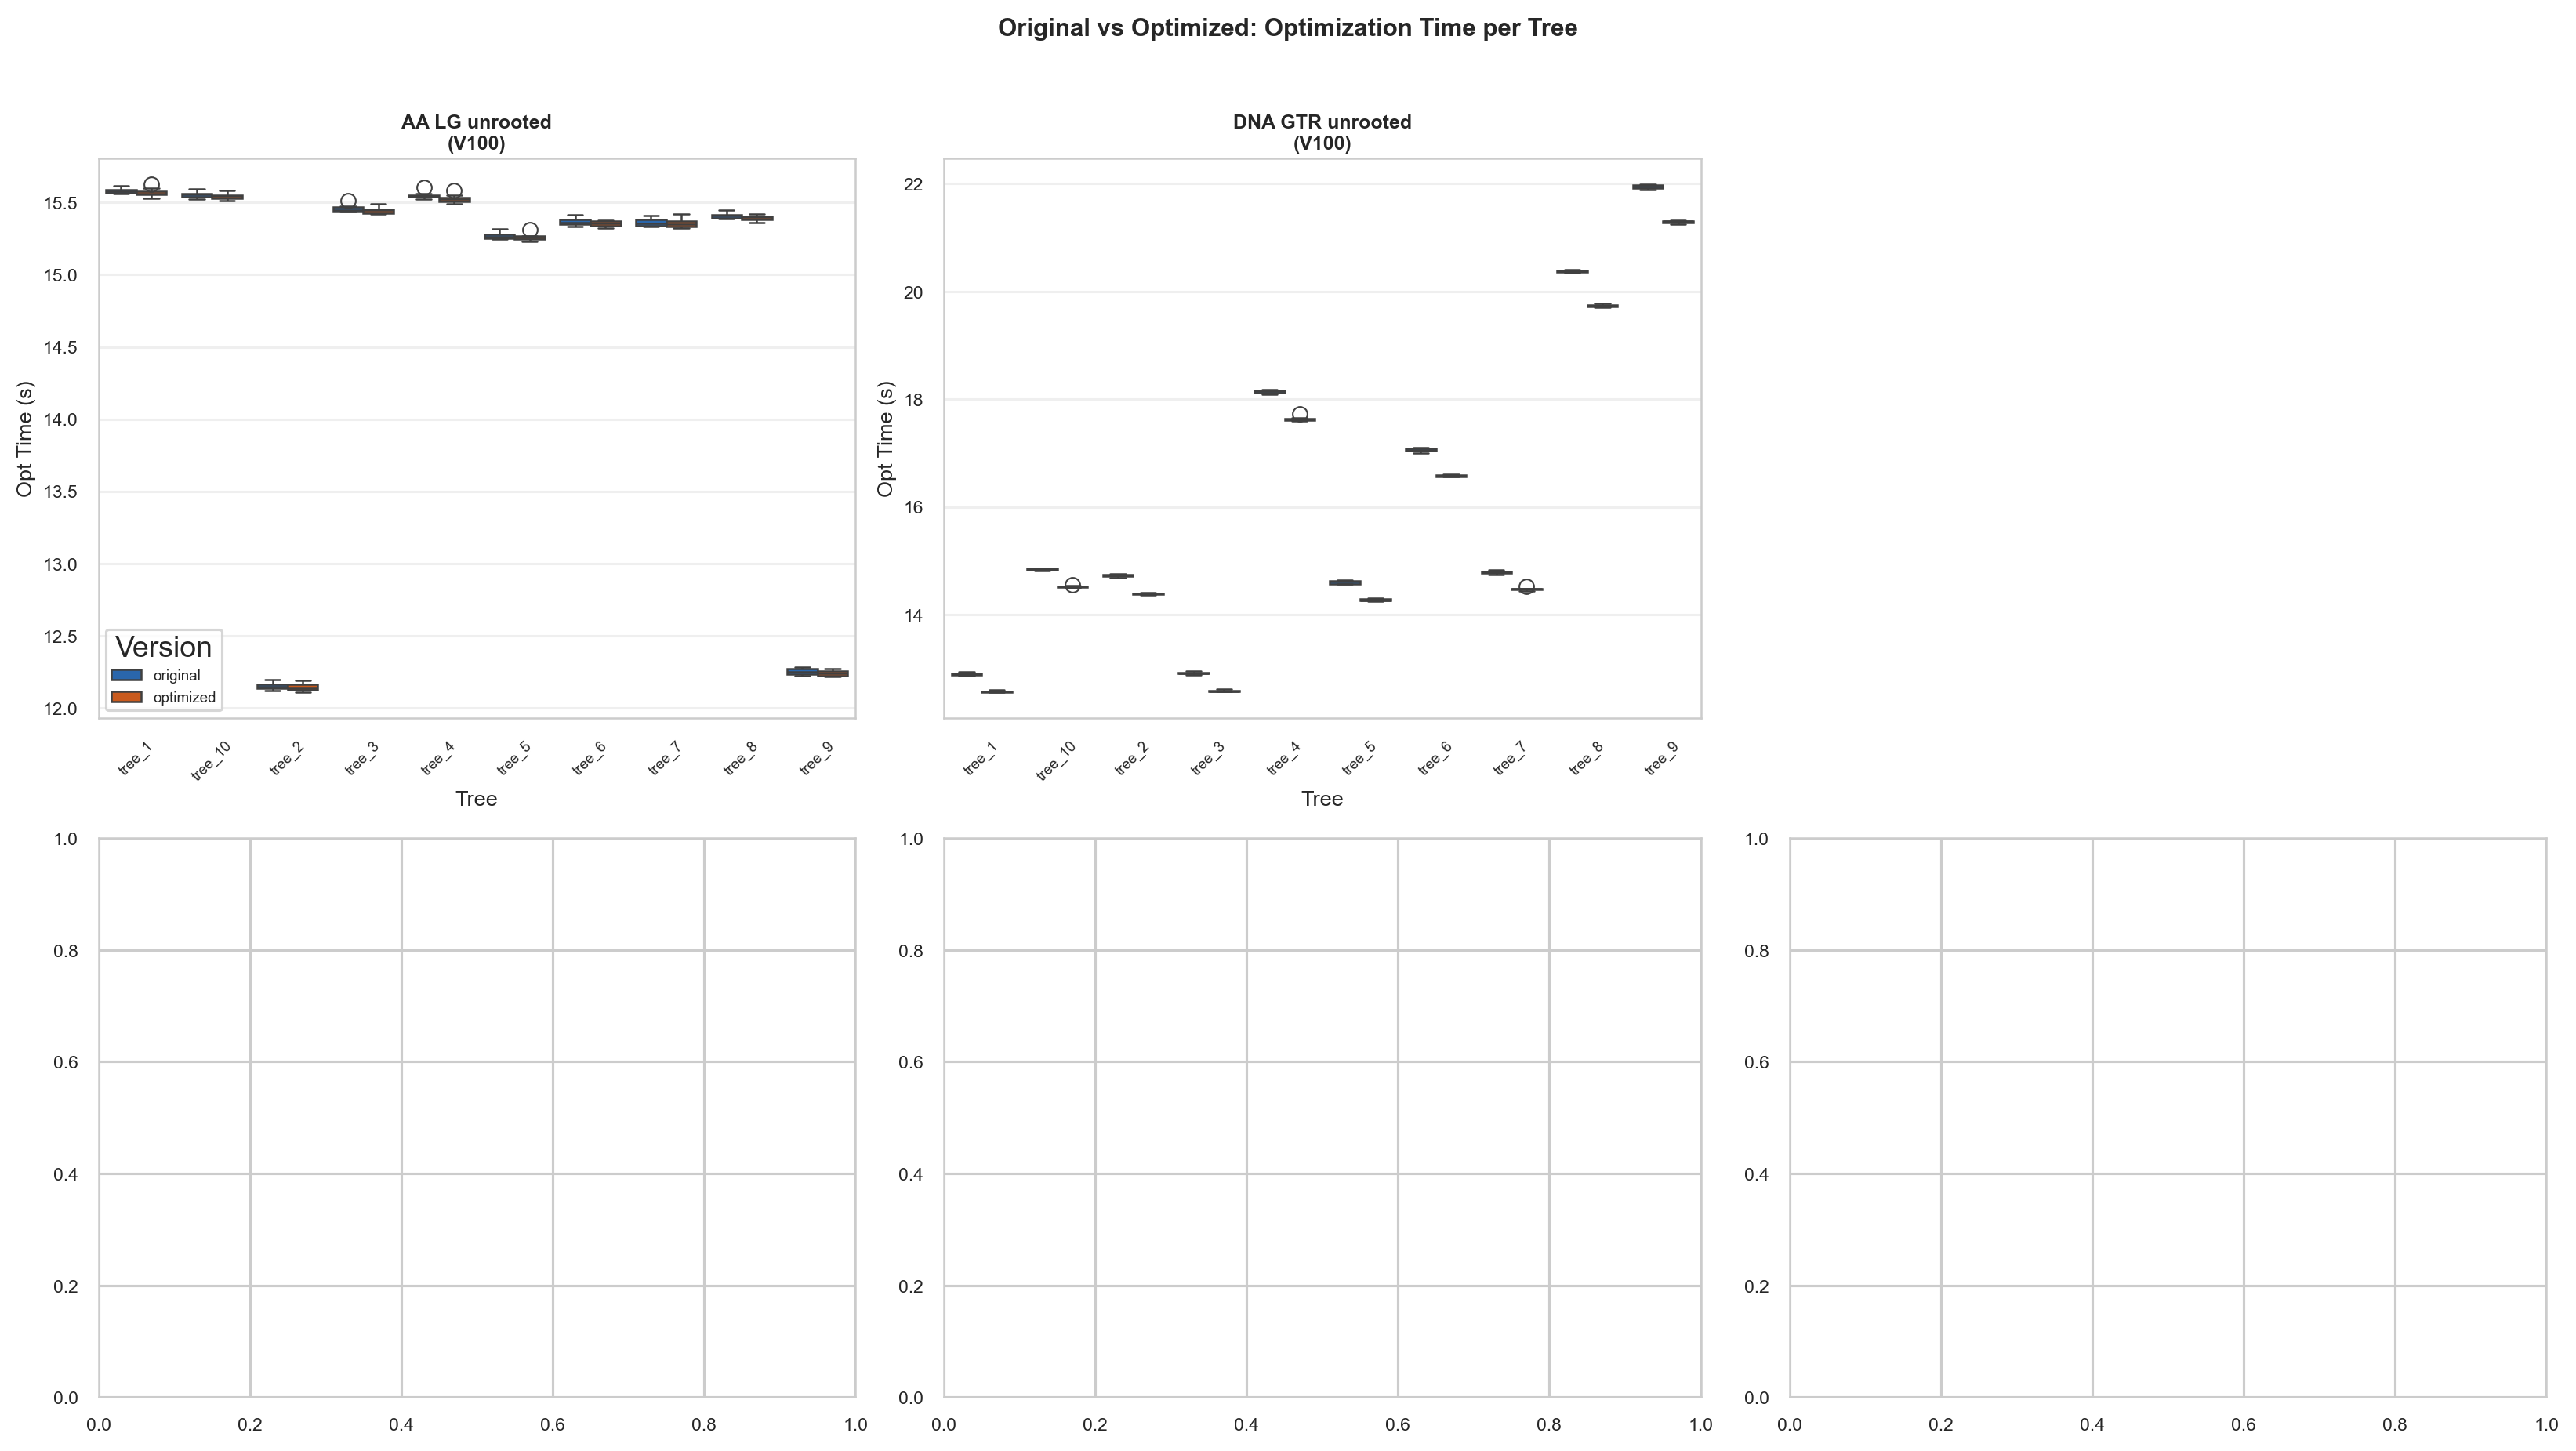

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()
plot_idx = 0
for _, combo in opt_combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    subset = df_all[(df_all['data_type']==dt) & (df_all['tree_type']==tt) & 
                    (df_all['model']==model) & (df_all['backend']==backend)]
    ax = axes[plot_idx]
    sns.boxplot(data=subset, x='treefile', y='opt_time', hue='source',
                hue_order=['original', 'optimized'], palette=SOURCE_PALETTE,
                linewidth=1.2, ax=ax)
    ax.set_title(f'{dt} {model} {tt}\n({backend.split("_")[-1]})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Opt Time (s)')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    if plot_idx > 0:
        ax.get_legend().remove()
    else:
        ax.legend(title='Version', fontsize=9)
    plot_idx += 1

# Hide unused subplot
if plot_idx < len(axes):
    axes[plot_idx].set_visible(False)

plt.suptitle('Original vs Optimized: Optimization Time per Tree', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_opt_time_per_tree.png", bbox_inches='tight', dpi=300)
plt.show()

# 6. Aggregated comparison (opt time + wallclock)

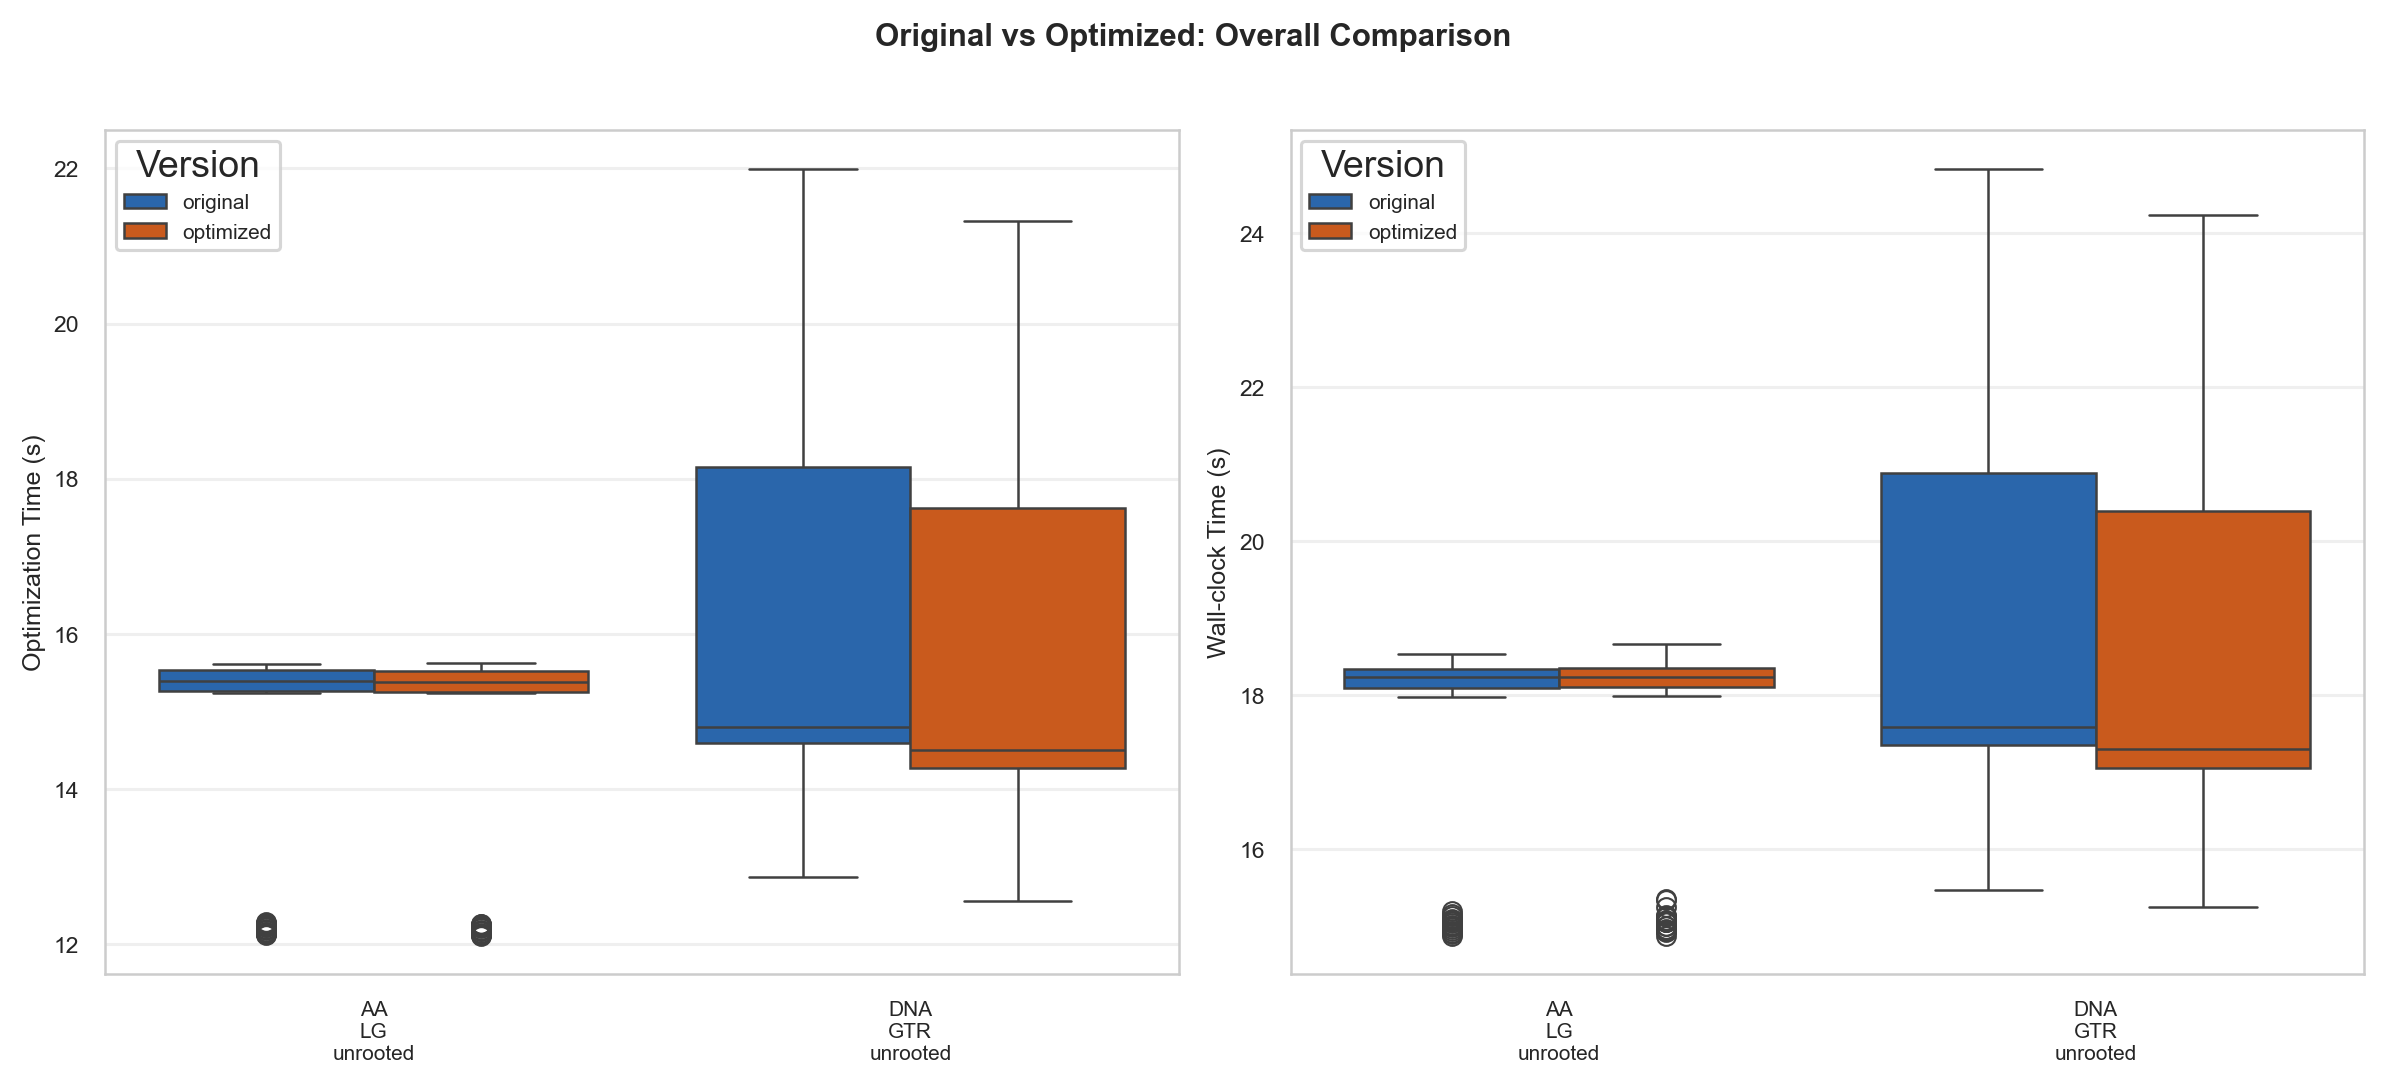

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, metric, label in [(ax1, 'opt_time', 'Optimization Time (s)'), 
                           (ax2, 'wallclock_time', 'Wall-clock Time (s)')]:
    sns.boxplot(data=df_all, x='combo', y=metric, hue='source',
                hue_order=['original', 'optimized'], palette=SOURCE_PALETTE,
                linewidth=1.2, ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel(label, fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(title='Version', fontsize=10)
    ax.tick_params(axis='x', labelsize=10)

plt.suptitle('Original vs Optimized: Overall Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_aggregated.png", bbox_inches='tight', dpi=300)
plt.show()

# 7. Optimization rounds comparison

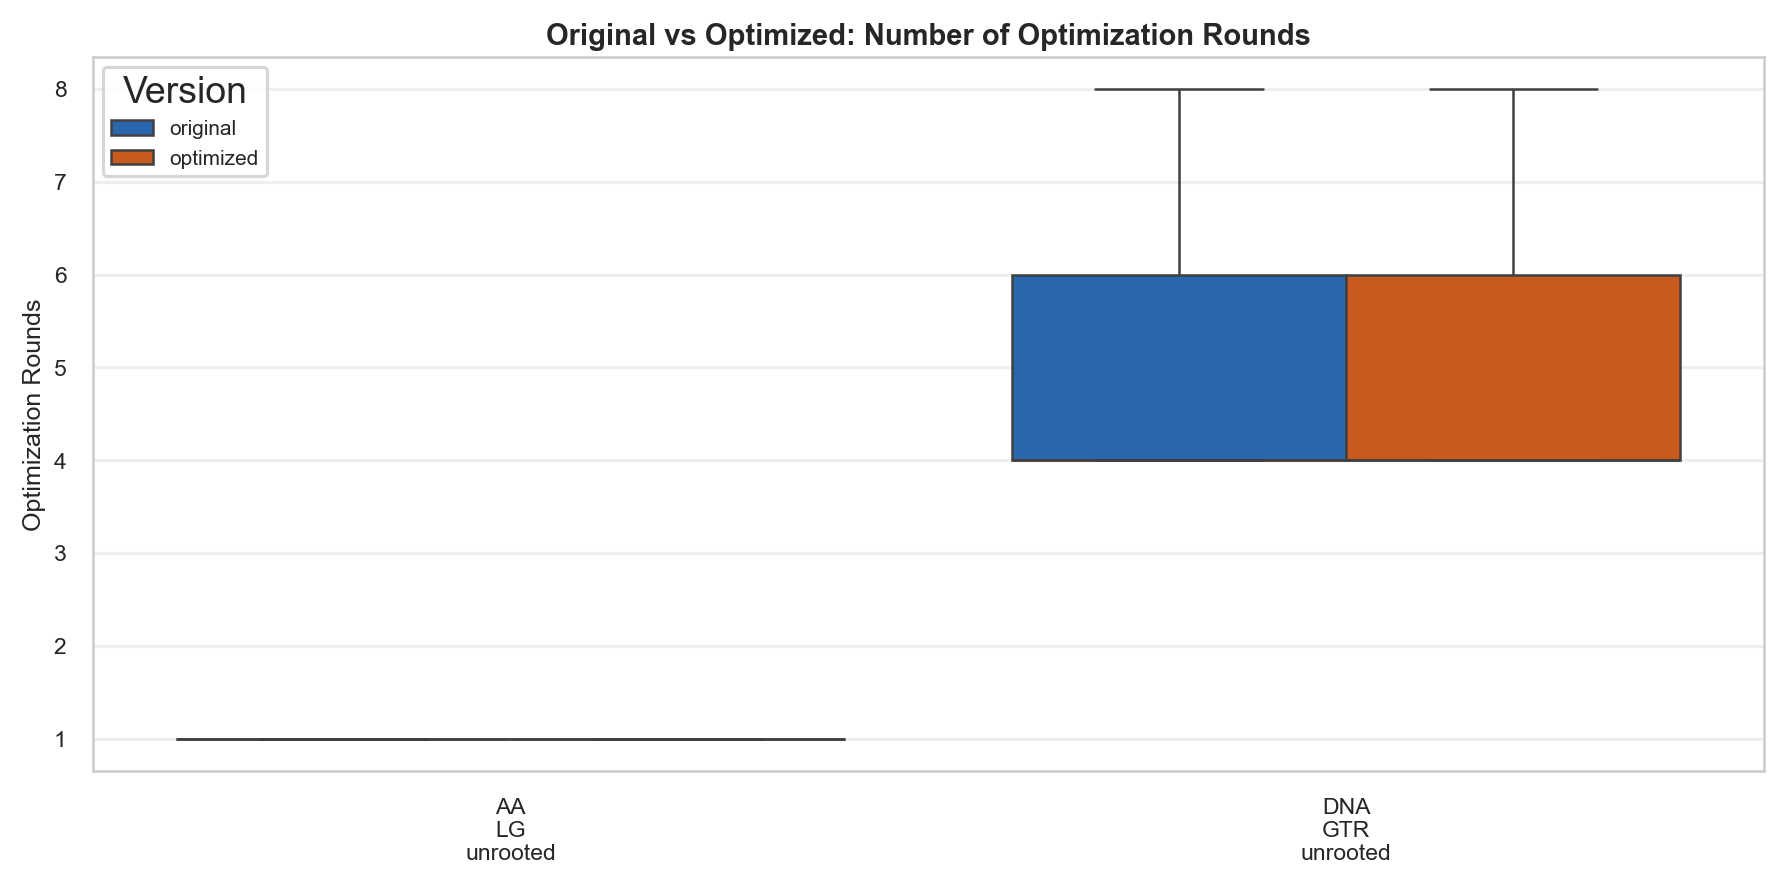

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_all, x='combo', y='opt_rounds', hue='source',
            hue_order=['original', 'optimized'], palette=SOURCE_PALETTE,
            linewidth=1.2, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Optimization Rounds', fontsize=12)
ax.set_title('Original vs Optimized: Number of Optimization Rounds', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(title='Version', fontsize=10)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_opt_rounds.png", bbox_inches='tight', dpi=300)
plt.show()

# 8. Likelihood comparison

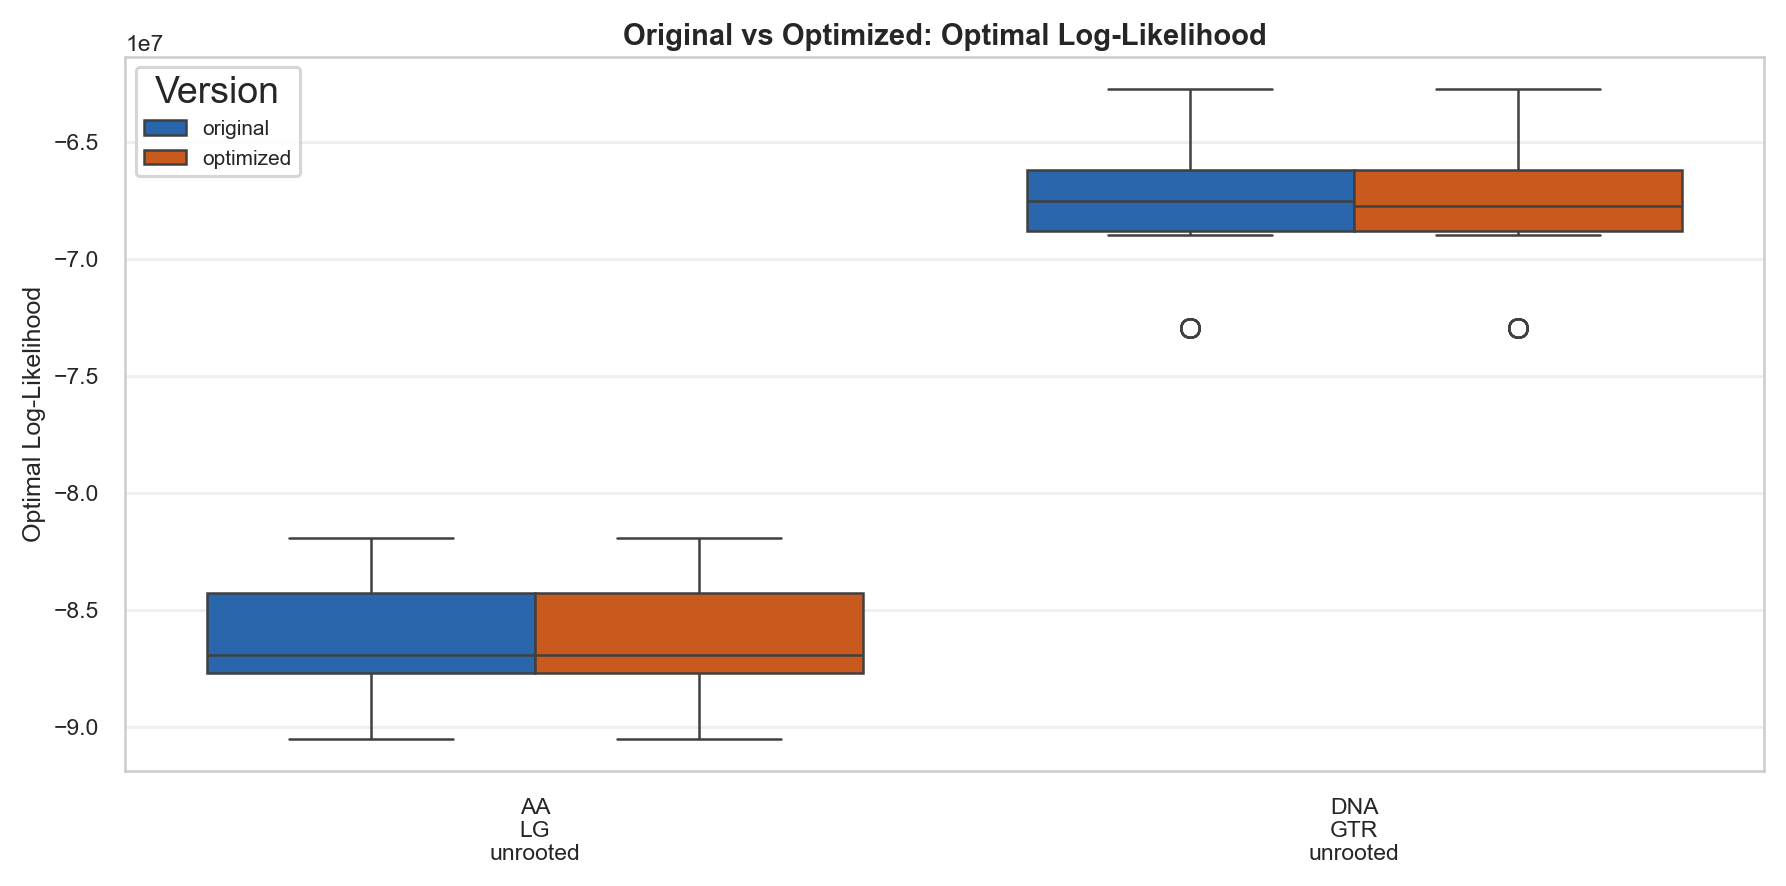

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_all, x='combo', y='optimal_likelihood', hue='source',
            hue_order=['original', 'optimized'], palette=SOURCE_PALETTE,
            linewidth=1.2, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Optimal Log-Likelihood', fontsize=12)
ax.set_title('Original vs Optimized: Optimal Log-Likelihood', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(title='Version', fontsize=10)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_likelihood.png", bbox_inches='tight', dpi=300)
plt.show()

# 9. Per-run speedup distribution

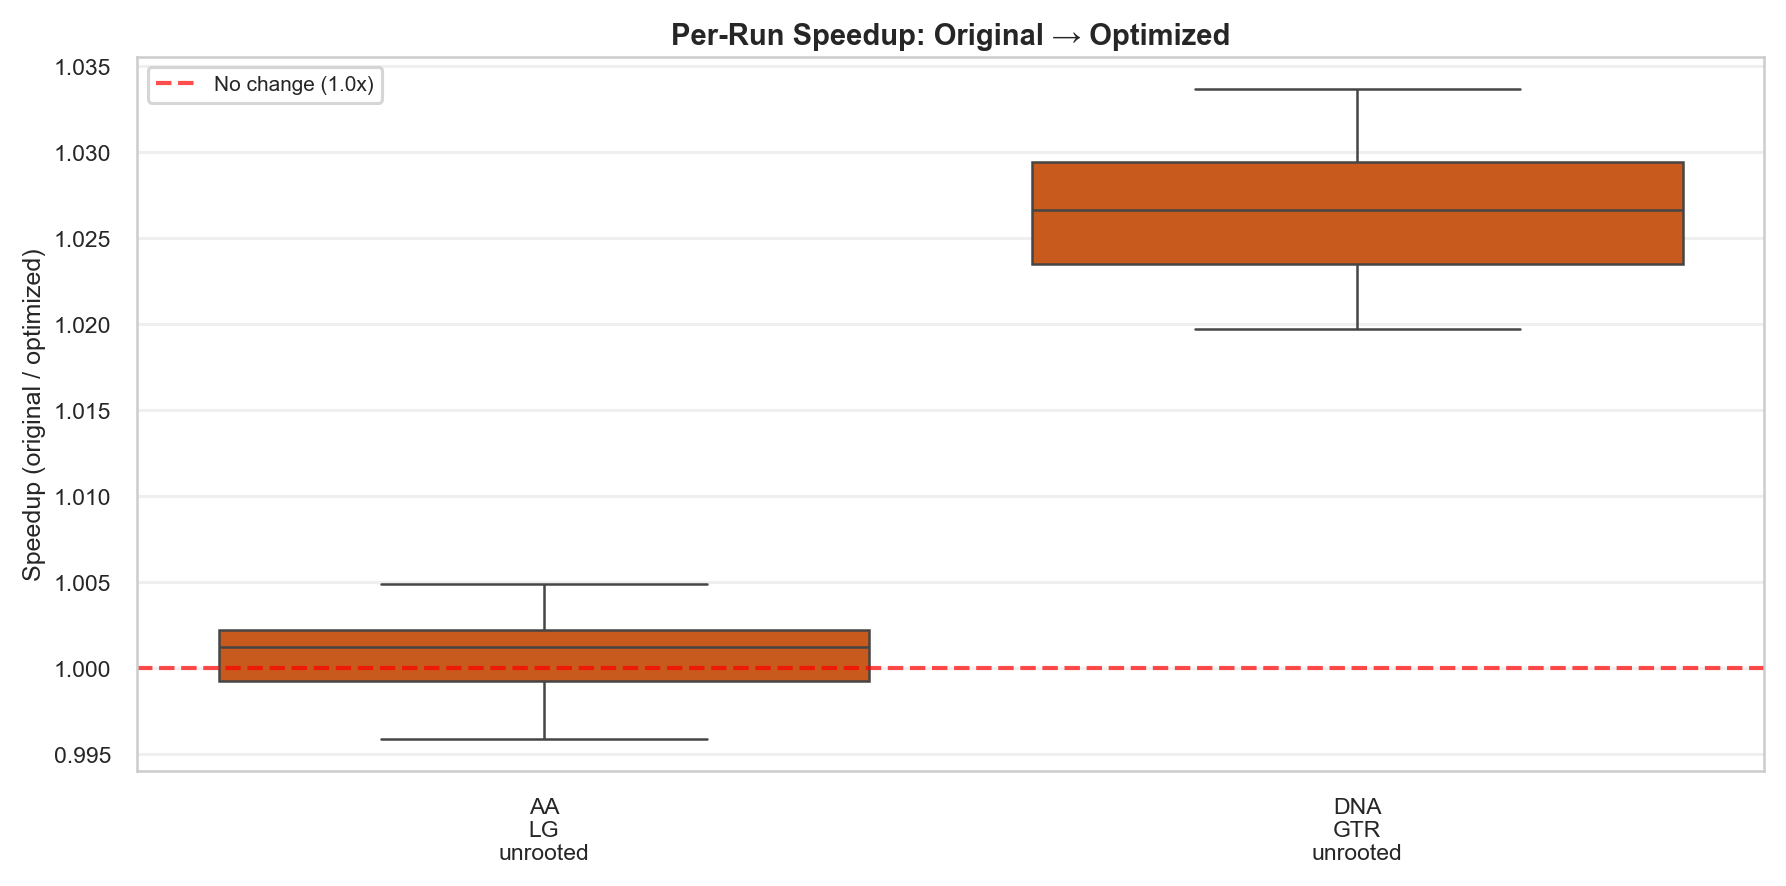

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
ratios_list = []
for _, combo in opt_combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    for tree in [f'tree_{i}' for i in range(1, 11)]:
        for run in range(1, 11):
            orig_val = df_orig[(df_orig['data_type']==dt) & (df_orig['tree_type']==tt) & 
                               (df_orig['model']==model) & (df_orig['backend']==backend) &
                               (df_orig['treefile']==tree) & (df_orig['run']==run)]['opt_time']
            opt_val = df_opt[(df_opt['data_type']==dt) & (df_opt['tree_type']==tt) & 
                             (df_opt['model']==model) & (df_opt['backend']==backend) &
                             (df_opt['treefile']==tree) & (df_opt['run']==run)]['opt_time']
            if len(orig_val) == 1 and len(opt_val) == 1:
                ratio = orig_val.values[0] / opt_val.values[0]
                ratios_list.append({
                    'combo': f'{dt}\n{model}\n{tt}',
                    'backend': backend,
                    'speedup': ratio
                })

df_ratios = pd.DataFrame(ratios_list)
if not df_ratios.empty:
    sns.boxplot(data=df_ratios, x='combo', y='speedup', linewidth=1.2,
                color='#E65100', ax=ax)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='No change (1.0x)')
    ax.set_xlabel('')
    ax.set_ylabel('Speedup (original / optimized)', fontsize=12)
    ax.set_title('Per-Run Speedup: Original \u2192 Optimized', fontsize=14, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(f"{cwd}/comparison_speedup_distribution.png", bbox_inches='tight', dpi=300)
    plt.show()

# 10. All backends + optimized GPU overlay (DNA GTR, AA LG)

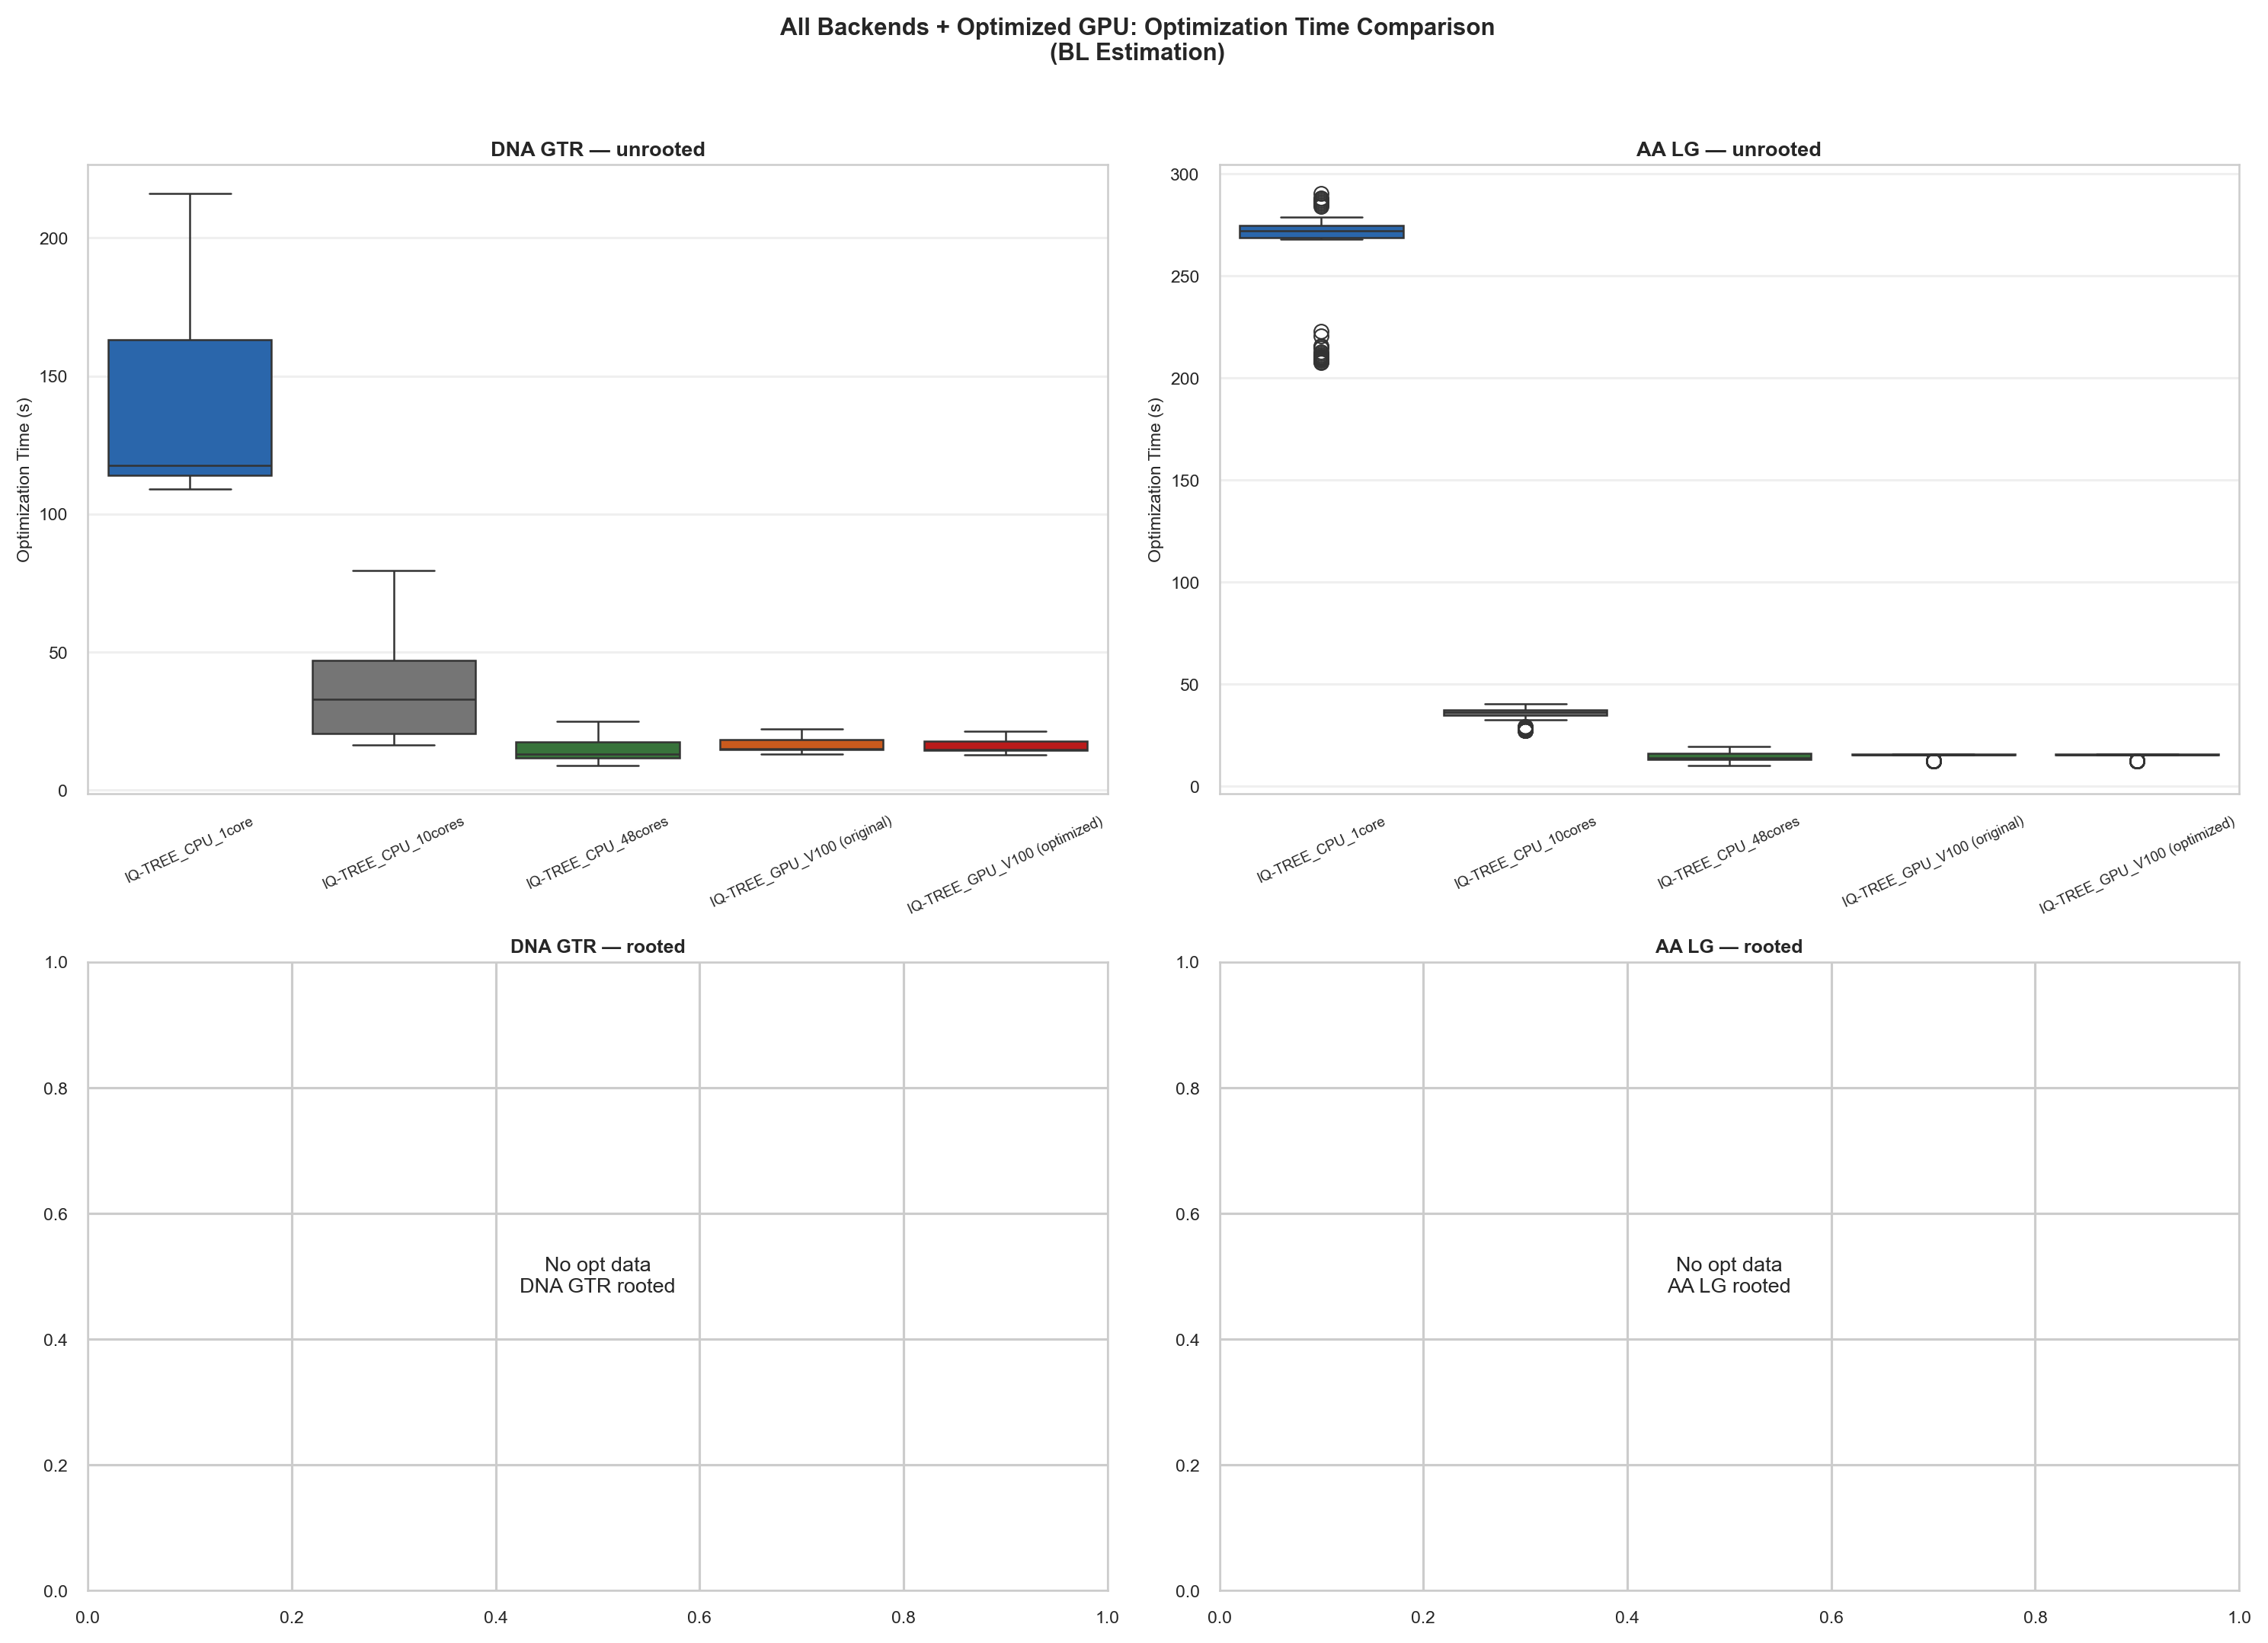

In [13]:
BACKEND_PALETTE_FULL = {
    'IQ-TREE_CPU_1core': '#1565C0', 'IQ-TREE_CPU_10cores': '#757575',
    'IQ-TREE_CPU_48cores': '#2E7D32', 'IQ-TREE_GPU_V100 (original)': '#E65100',
    'IQ-TREE_GPU_V100 (optimized)': '#D50000',
}

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

for col, (dt, model) in enumerate([('DNA', 'GTR'), ('AA', 'LG')]):
    for row, tt in enumerate(['unrooted', 'rooted']):
        ax = axes[row][col]
        
        # Get original data for this model (all backends)
        orig_sub = df_orig_full[(df_orig_full['data_type']==dt) & (df_orig_full['tree_type']==tt) & 
                                (df_orig_full['model']==model)].copy()
        orig_sub['backend_label'] = orig_sub['backend'].apply(
            lambda x: x + ' (original)' if x == 'IQ-TREE_GPU_V100' else x)
        
        # Get opt data
        opt_sub = df_opt[(df_opt['data_type']==dt) & (df_opt['tree_type']==tt) & 
                         (df_opt['model']==model)].copy()
        if len(opt_sub) == 0:
            ax.text(0.5, 0.5, f'No opt data\n{dt} {model} {tt}',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{dt} {model} \u2014 {tt}', fontsize=12, fontweight='bold')
            continue
        opt_sub['backend_label'] = 'IQ-TREE_GPU_V100 (optimized)'
        
        combined = pd.concat([orig_sub, opt_sub], ignore_index=True)
        order = ['IQ-TREE_CPU_1core', 'IQ-TREE_CPU_10cores', 'IQ-TREE_CPU_48cores', 
                 'IQ-TREE_GPU_V100 (original)', 'IQ-TREE_GPU_V100 (optimized)']
        present = [o for o in order if o in combined['backend_label'].unique()]
        
        sns.boxplot(data=combined, x='backend_label', y='opt_time', order=present,
                    hue='backend_label', hue_order=present,
                    palette=BACKEND_PALETTE_FULL, linewidth=1.2, ax=ax, legend=False)
        ax.set_title(f'{dt} {model} \u2014 {tt}', fontsize=13, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Optimization Time (s)', fontsize=11)
        ax.tick_params(axis='x', rotation=25, labelsize=9)
        ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('All Backends + Optimized GPU: Optimization Time Comparison\n(BL Estimation)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_all_backends_GTR_LG.png", bbox_inches='tight', dpi=300)
plt.show()

# 11. All backends + optimized CPU overlay (AA Poisson)

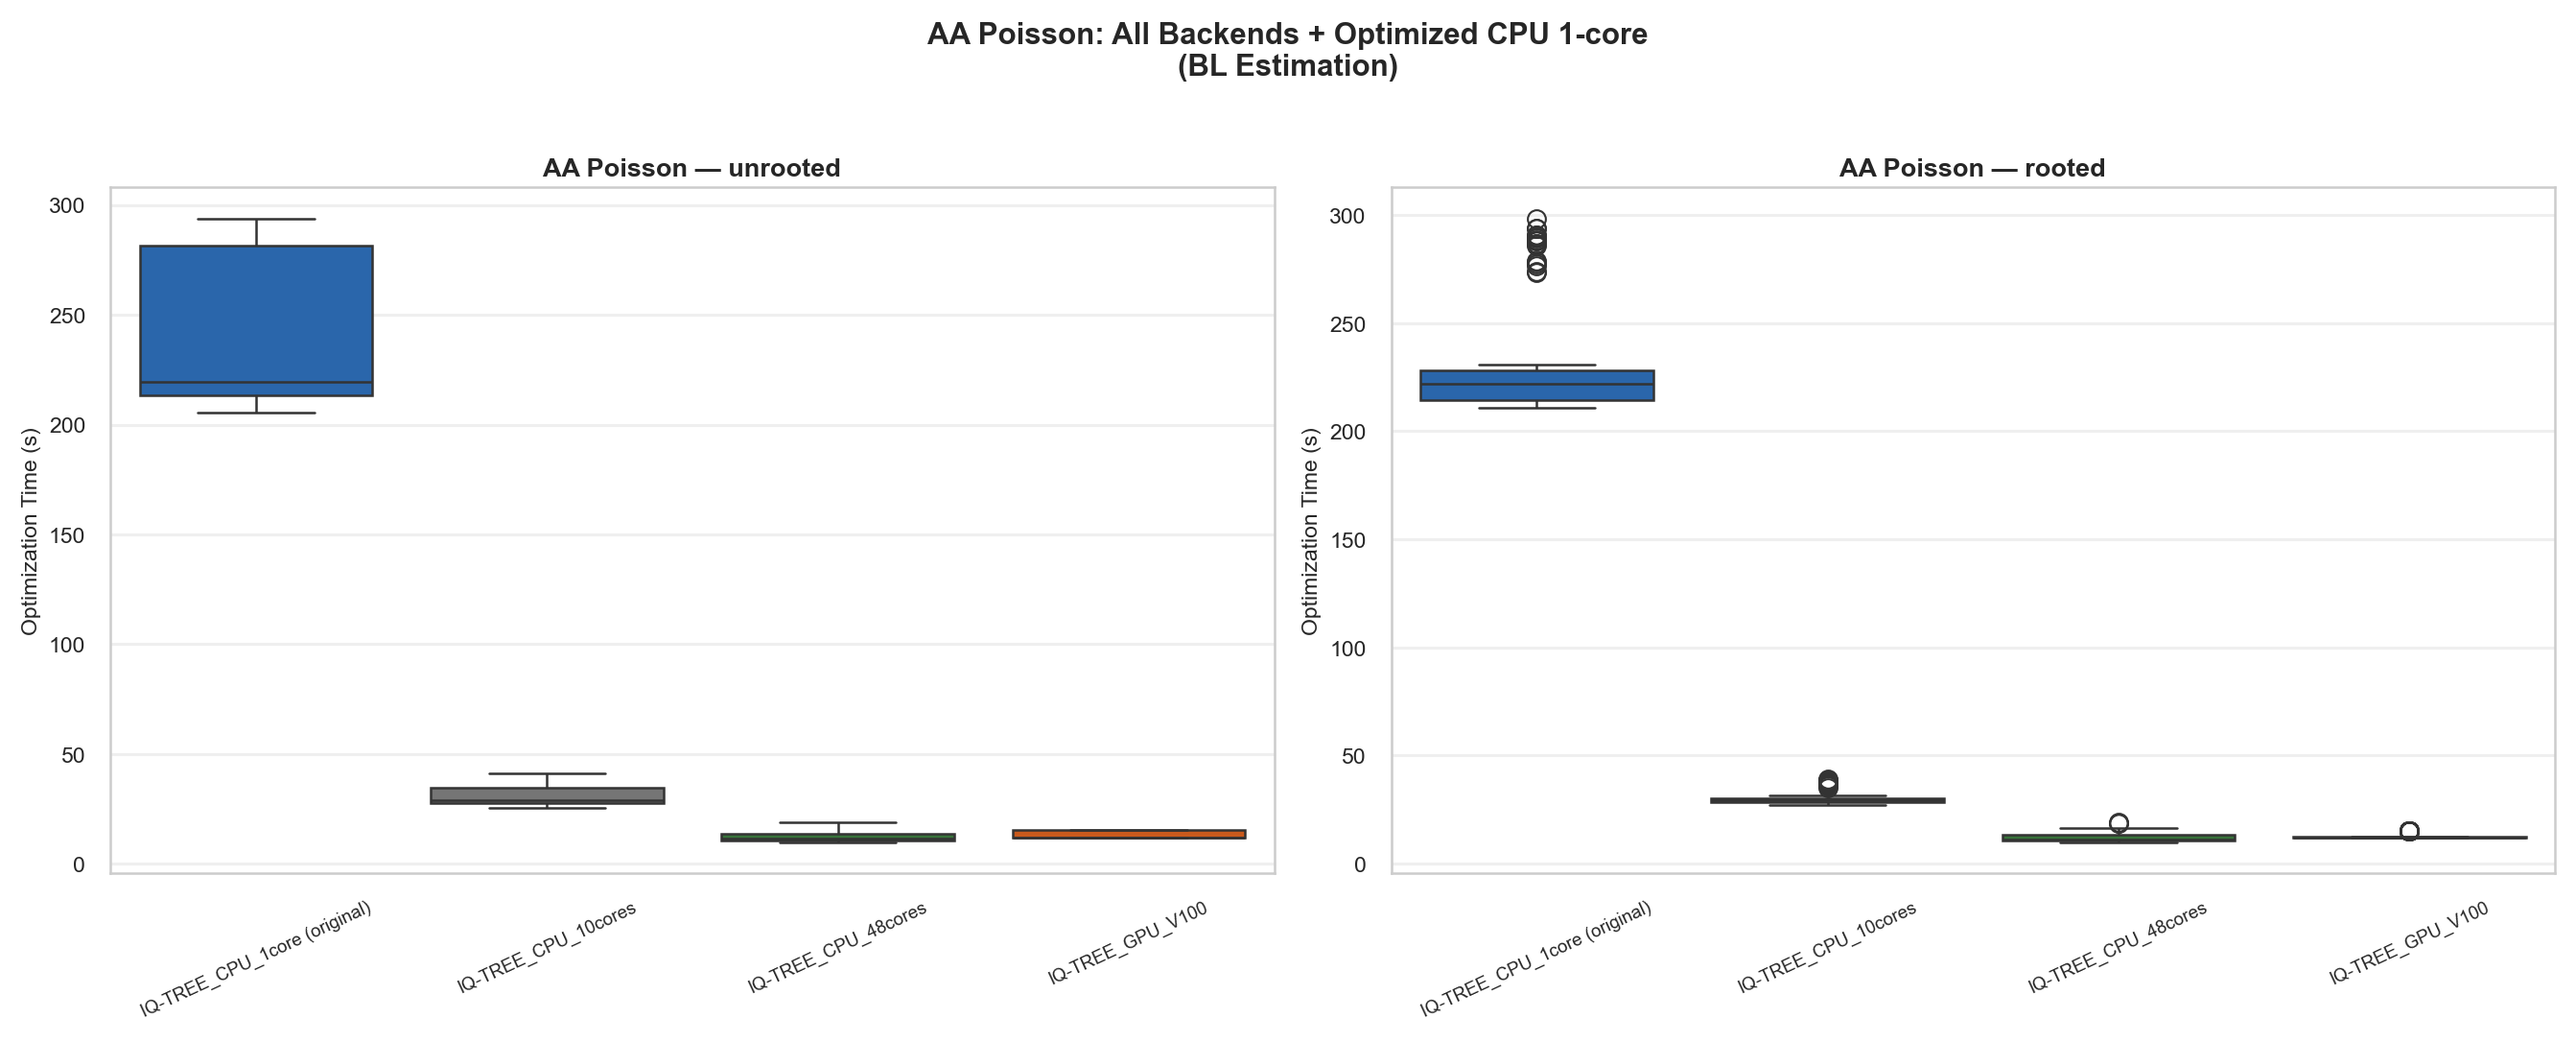

In [14]:
BACKEND_PALETTE_POISSON = {
    'IQ-TREE_CPU_1core (original)': '#1565C0', 
    'IQ-TREE_CPU_1core (optimized)': '#0D47A1',
    'IQ-TREE_CPU_10cores': '#757575',
    'IQ-TREE_CPU_48cores': '#2E7D32', 
    'IQ-TREE_GPU_V100': '#E65100',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for ax, tt in [(ax1, 'unrooted'), (ax2, 'rooted')]:
    orig_sub = df_orig_full[(df_orig_full['data_type']=='AA') & (df_orig_full['tree_type']==tt) & 
                            (df_orig_full['model']=='Poisson')].copy()
    orig_sub['backend_label'] = orig_sub['backend'].apply(
        lambda x: x + ' (original)' if x == 'IQ-TREE_CPU_1core' else x)
    
    opt_sub = df_opt[(df_opt['data_type']=='AA') & (df_opt['tree_type']==tt) & 
                     (df_opt['model']=='Poisson')].copy()
    if len(opt_sub) > 0:
        opt_sub['backend_label'] = 'IQ-TREE_CPU_1core (optimized)'
        combined = pd.concat([orig_sub, opt_sub], ignore_index=True)
    else:
        combined = orig_sub
    
    order = ['IQ-TREE_CPU_1core (original)', 'IQ-TREE_CPU_1core (optimized)',
             'IQ-TREE_CPU_10cores', 'IQ-TREE_CPU_48cores', 'IQ-TREE_GPU_V100']
    present = [o for o in order if o in combined['backend_label'].unique()]
    
    sns.boxplot(data=combined, x='backend_label', y='opt_time', order=present,
                hue='backend_label', hue_order=present,
                palette=BACKEND_PALETTE_POISSON, linewidth=1.2, ax=ax, legend=False)
    ax.set_title(f'AA Poisson \u2014 {tt}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Optimization Time (s)', fontsize=11)
    ax.tick_params(axis='x', rotation=25, labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('AA Poisson: All Backends + Optimized CPU 1-core\n(BL Estimation)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{cwd}/comparison_all_backends_Poisson.png", bbox_inches='tight', dpi=300)
plt.show()

# 12. Missing data check

In [15]:
print("=== MISSING DATA in OPT ===")
missing = []
for _, combo in opt_combos.iterrows():
    dt, tt, model, backend = combo['data_type'], combo['tree_type'], combo['model'], combo['backend']
    for tree in [f'tree_{i}' for i in range(1, 11)]:
        subset = df_opt[(df_opt['data_type']==dt) & (df_opt['tree_type']==tt) & 
                        (df_opt['model']==model) & (df_opt['backend']==backend) &
                        (df_opt['treefile']==tree)]
        for r in range(1, 11):
            if r not in subset['run'].values:
                be_map = {'IQ-TREE_CPU_1core':'VANILA','IQ-TREE_GPU_V100':'OPENACC'}
                missing.append(f"{dt}, {tt}, {be_map.get(backend,backend)}, {model}, {tree}, run{r}")

if missing:
    print(f"Missing runs ({len(missing)}):")
    for m in missing:
        print(f"  {m}")
else:
    print("No missing data in OPT!")

=== MISSING DATA in OPT ===
No missing data in OPT!
